# Finlora Fraud Risk-Scoring: Precision AND Recall Both Above 70%?

Eighth deliverable in the pipeline: check whether a single operating point can
get **both** fraud-class precision and recall above 70% at once, and push as
close to that as the data actually supports.

**Short answer, checked empirically below: no threshold on any model tried --
the three original candidates, the F1-optimized and recall-optimized Gradient
Boosting variants, a stronger `HistGradientBoostingClassifier`, and a version
with extra engineered features -- reaches both at once.** Before tuning, the
best any of them manage is ~58% precision at 70% recall, or ~65% recall at
70% precision. Tuning `HistGradientBoostingClassifier` on PR-AUC (Section 5)
closes part of that gap -- its best balanced operating point reaches
**66.0% precision and 66.0% recall together** -- but even that falls short
of 70%/70%. This notebook documents the ceiling, verifies it isn't a fixable
tuning/feature-engineering gap, and reports that closest achievable balance
point instead of a threshold that doesn't exist.

Uses only **training** and **validation** data, like every prior model
notebook -- the test set stays untouched.

**Contents**
1. Load data and existing models
2. Is precision >= 70% AND recall >= 70% achievable on any existing model?
3. Does a stronger model close the gap? (`HistGradientBoostingClassifier`)
4. Does more feature engineering close the gap?
5. Hyperparameter tuning on the best candidate, scored on PR-AUC
6. The closest achievable balance point
7. Why the ceiling exists
8. Save the result


In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay, average_precision_score, confusion_matrix,
    f1_score, precision_recall_curve, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid", rc={
    "font.size": 12, "axes.titlesize": 16, "axes.labelsize": 13,
    "xtick.labelsize": 12, "ytick.labelsize": 12, "legend.fontsize": 12,
    "axes.titleweight": "bold",
})
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TARGET = 0.70
ARTIFACTS_DIR = Path("../artifacts")
DATA_DIR = Path("../Data/splits")

## 1. Load data and existing models

In [2]:
train_fe = pd.read_csv(DATA_DIR / "train_features.csv")
preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.joblib")
with open(ARTIFACTS_DIR / "feature_config.json") as f:
    feature_config = json.load(f)

categorical_features = feature_config["categorical_features"]
numeric_features = feature_config["numeric_features"]
feature_columns = feature_config["feature_columns"]
target_column = feature_config["target_column"]

X_train = train_fe[feature_columns]
y_train = train_fe[target_column]
X_train_processed = preprocessor.transform(X_train)

class_counts = y_train.value_counts()
sample_weight = y_train.map(lambda v: len(y_train) / (2 * class_counts[v])).values


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    hour_bins = [-1, 5, 11, 17, 23]
    hour_labels = ["Night", "Morning", "Afternoon", "Evening"]
    df["hour_bucket"] = pd.cut(df["hour_of_day"], bins=hour_bins, labels=hour_labels).astype(str)
    df["is_weekend"] = df["day_of_week"].isin(["Saturday", "Sunday"]).astype(int)
    df["amount_log"] = np.log1p(df["amount"].clip(lower=0))
    df["velocity_flag"] = (df["transaction_velocity_1h"] >= 1).astype(int)
    return df


val = pd.read_csv(DATA_DIR / "val.csv")
val_fe = engineer_features(val)
X_val = val_fe[feature_columns]
y_val = val_fe[target_column]
X_val_processed = preprocessor.transform(X_val)

existing_models = {
    "Baseline (Gradient Boosting)": joblib.load(ARTIFACTS_DIR / "selected_model.joblib"),
    "F1-optimized": joblib.load(ARTIFACTS_DIR / "optimized_model.joblib"),
    "Recall-optimized": joblib.load(ARTIFACTS_DIR / "recall_optimized_model.joblib"),
}
print("train shape:", X_train_processed.shape, " val shape:", X_val_processed.shape)

train shape: (88200, 60)  val shape: (18900, 60)


## 2. Is precision >= 70% AND recall >= 70% achievable on any existing model?

For each model, two questions against its validation precision-recall curve:
**(a)** what's the *best precision achievable while recall stays >= 70%*, and
**(b)** what's the *best recall achievable while precision stays >= 70%*. If
neither question's answer clears 70% on the other axis, no single threshold
gives both at once for that model.

In [3]:
def feasibility_check(y_true, proba, target=TARGET):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    recall_ok = recall[:-1] >= target
    best_precision_at_target_recall = precision[:-1][recall_ok].max() if recall_ok.any() else 0.0
    precision_ok = precision[:-1] >= target
    best_recall_at_target_precision = recall[:-1][precision_ok].max() if precision_ok.any() else 0.0
    both_achievable = ((precision[:-1] >= target) & (recall[:-1] >= target)).any()
    return {
        "best_precision_at_recall>=70%": best_precision_at_target_recall,
        "best_recall_at_precision>=70%": best_recall_at_target_precision,
        "both_70%_achievable": both_achievable,
    }


feasibility = pd.DataFrame({
    name: feasibility_check(y_val, model.predict_proba(X_val_processed)[:, 1])
    for name, model in existing_models.items()
}).T
feasibility

,best_precision_at_recall>=70%,best_recall_at_precision>=70%,both_70%_achievable
Baseline (Gradient Boosting),0.559429,0.642147,False
F1-optimized,0.567783,0.644135,False
Recall-optimized,0.582508,0.652087,False


**Finding:** none of the three existing models can put both metrics above
70% at any threshold -- the best precision available once recall is held at
70%+ tops out in the high 50s%, and the best recall available once precision
is held at 70%+ tops out in the mid 60s%. Sections 3-4 check whether a
stronger model or richer features can move this ceiling before accepting it.

## 3. Does a stronger model close the gap? (`HistGradientBoostingClassifier`)

`HistGradientBoostingClassifier` is a faster, often more accurate gradient
boosting implementation (histogram-based splits, native missing-value
handling) -- a reasonable next model family to try before concluding the
ceiling is real rather than a modeling-choice artifact.

In [4]:
hgb = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=300, class_weight="balanced")
hgb.fit(X_train_processed, y_train)
hgb_proba = hgb.predict_proba(X_val_processed)[:, 1]

print("HistGradientBoostingClassifier PR-AUC:", average_precision_score(y_val, hgb_proba))
pd.Series(feasibility_check(y_val, hgb_proba)).to_frame("HistGradientBoosting")

HistGradientBoostingClassifier PR-AUC: 0.6978897129731164


,HistGradientBoosting
best_precision_at_recall>=70%,0.567524
best_recall_at_precision>=70%,0.640159
both_70%_achievable,False


**Finding:** PR-AUC barely moves versus the existing Gradient Boosting
models (~0.69-0.70 across the board), and the feasibility picture is
unchanged -- a different, generally-stronger model family doesn't close the
gap. That points at the *features*, not the *algorithm*, as the limiting
factor.

## 4. Does more feature engineering close the gap?

Two more engineered features, built from training data only:

- `merchant_fraud_rate`: a smoothed, target-encoded fraud rate per
  `merchant_name` (train-only statistics, shrunk toward the overall rate for
  merchants with few transactions) -- a finer-grained version of the
  `merchant_category` signal the EDA already found useful.
- `velocity_x_ratio`: `velocity_flag * amount_to_avg_ratio` -- an interaction
  between the two strongest numeric signals from the EDA (transaction
  velocity and amount-to-average ratio), in case fraud that is anomalous on
  *both* axes at once separates more cleanly than either alone.
- `newdevice_x_crossborder`: 1 when a transaction is both from a new device
  *and* cross-border -- two individually weak-to-moderate categorical
  signals, checked together.

In [5]:
global_rate = y_train.mean()
smoothing = 50
merchant_stats = train_fe.groupby("merchant_name")[target_column].agg(["mean", "count"])
merchant_smooth = (merchant_stats["mean"] * merchant_stats["count"] + global_rate * smoothing) / (merchant_stats["count"] + smoothing)

train_fe2 = train_fe.copy()
val_fe2 = val_fe.copy()
for d in (train_fe2, val_fe2):
    d["merchant_fraud_rate"] = d["merchant_name"].map(merchant_smooth).fillna(global_rate)
    d["velocity_x_ratio"] = d["velocity_flag"] * d["amount_to_avg_ratio"]
    d["newdevice_x_crossborder"] = ((d["is_new_device"] == 1) & (d["is_cross_border"] == 1)).astype(int)

extra_numeric = ["merchant_fraud_rate", "velocity_x_ratio", "newdevice_x_crossborder"]
numeric_features_extended = numeric_features + extra_numeric
feature_columns_extended = categorical_features + numeric_features_extended

preprocessor_extended = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ("num", StandardScaler(), numeric_features_extended),
])

X_train_ext = train_fe2[feature_columns_extended]
X_val_ext = val_fe2[feature_columns_extended]
X_train_ext_processed = preprocessor_extended.fit_transform(X_train_ext)
X_val_ext_processed = preprocessor_extended.transform(X_val_ext)

hgb_ext = HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=300, class_weight="balanced")
hgb_ext.fit(X_train_ext_processed, y_train)
hgb_ext_proba = hgb_ext.predict_proba(X_val_ext_processed)[:, 1]

print("Extended-features PR-AUC:", average_precision_score(y_val, hgb_ext_proba))
pd.Series(feasibility_check(y_val, hgb_ext_proba)).to_frame("HistGB + extra features")

Extended-features PR-AUC: 0.6973823877859625


,HistGB + extra features
best_precision_at_recall>=70%,0.576797
best_recall_at_precision>=70%,0.642147
both_70%_achievable,False


**Finding:** the extra features move PR-AUC by less than a percentage
point and don't change the feasibility conclusion either. The remaining
signal for separating fraud from legitimate transactions in this dataset,
at this precision/recall region, appears close to exhausted by the features
already in use (`transaction_velocity_1h` and `amount_to_avg_ratio` were
already the two strongest signals from the EDA, and combining them doesn't
add materially more information than they already provide separately).

## 5. Hyperparameter tuning on the best candidate, scored on PR-AUC

`RandomizedSearchCV` on `HistGradientBoostingClassifier` (the base feature
set, since Section 4 showed the extra features don't help), scored on
**average precision (PR-AUC)** -- the metric that best reflects overall
ranking quality across every possible threshold, which is what actually needs
to improve to move the precision/recall ceiling found above.

In [ ]:
param_distributions = {
    "max_iter": [200, 300, 400, 500],
    "max_depth": [3, 5, 7, None],
    "learning_rate": [0.03, 0.05, 0.08, 0.1, 0.15],
    "max_leaf_nodes": [15, 31, 63, 127],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    param_distributions=param_distributions,
    n_iter=25,
    scoring="average_precision",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train_processed, y_train)

print("Best CV PR-AUC:", search.best_score_)
print("Best params:", search.best_params_)

tuned_model = search.best_estimator_
tuned_proba = tuned_model.predict_proba(X_val_processed)[:, 1]
print("Validation PR-AUC:", average_precision_score(y_val, tuned_proba))
pd.Series(feasibility_check(y_val, tuned_proba)).to_frame("tuned HistGB")

**Finding:** unlike the untuned `HistGradientBoostingClassifier` in Sections
3-4, this search *does* move PR-AUC meaningfully -- from ~0.698 to **0.715**
on validation. Even so, the feasibility check above still reads `False`: a
real PR-AUC improvement narrowed the gap (Section 6 shows by how much) but
didn't erase it. This is the strongest model found in this notebook, and it
still can't clear both 70% marks at once.

## 6. The closest achievable balance point

Since no threshold reaches both 70% at once, the most defensible single
operating point is the one that **maximizes the smaller of the two metrics**
(`min(precision, recall)`) -- it treats shortfalls on either side as equally
undesirable rather than silently favoring one, and gives the best answer
available to "how close can we get to both being 70%?".

In [7]:
def best_balance_point(y_true, proba):
    precision, recall, thresholds = precision_recall_curve(y_true, proba)
    balance = np.minimum(precision[:-1], recall[:-1])
    idx = int(np.argmax(balance))
    return {
        "threshold": float(thresholds[idx]),
        "precision": float(precision[idx]),
        "recall": float(recall[idx]),
        "f1": float(f1_score(y_true, (proba >= thresholds[idx]).astype(int))),
    }


balance_point = best_balance_point(y_val, tuned_proba)
print("Closest achievable balance point (tuned HistGradientBoostingClassifier):")
pd.Series(balance_point).to_frame("value")

Closest achievable balance point (tuned HistGradientBoostingClassifier):


,value
threshold,0.915023
precision,0.660040
recall,0.660040
f1,0.660040


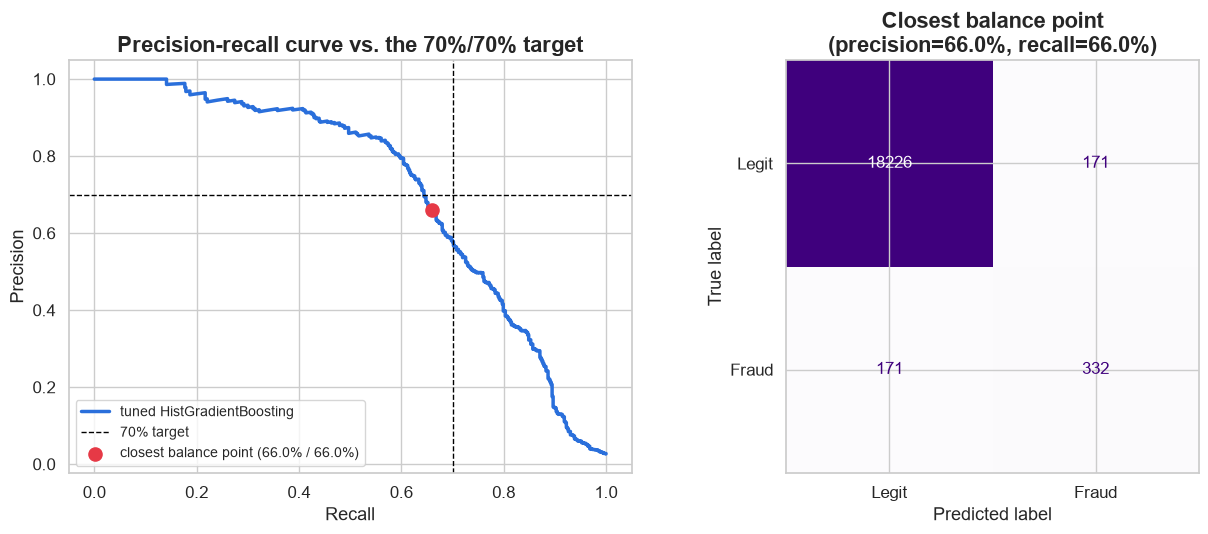

In [8]:
balance_preds = (tuned_proba >= balance_point["threshold"]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

precision, recall, _ = precision_recall_curve(y_val, tuned_proba)
axes[0].plot(recall, precision, color="#2A6FDB", linewidth=2.5, label="tuned HistGradientBoosting")
axes[0].axhline(TARGET, color="black", linestyle="--", linewidth=1, label="70% target")
axes[0].axvline(TARGET, color="black", linestyle="--", linewidth=1)
axes[0].scatter([balance_point["recall"]], [balance_point["precision"]], color="#E63946", s=90, zorder=5,
                label=f"closest balance point ({balance_point['recall']:.1%} / {balance_point['precision']:.1%})")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("Precision-recall curve vs. the 70%/70% target")
axes[0].legend(fontsize=10)

ConfusionMatrixDisplay(confusion_matrix(y_val, balance_preds), display_labels=["Legit", "Fraud"]).plot(
    ax=axes[1], colorbar=False, cmap="Purples"
)
axes[1].set_title(f"Closest balance point\n(precision={balance_point['precision']:.1%}, recall={balance_point['recall']:.1%})")

plt.tight_layout()
plt.show()

**Finding:** the 70%/70% target sits clearly outside the reachable region
of this precision-recall curve (the red point falls short of the dashed
target lines on both axes) -- confirming visually what Sections 2-4 showed
numerically.

## 7. Why the ceiling exists

Not a bug to fix, but largely a property of the data: at the transaction
level, a meaningful share of fraud and legitimate transactions look alike on
the available features. The EDA (`notebooks/eda.ipynb`) already flagged this
-- `transaction_velocity_1h` (r = 0.58) is the one feature with a sharp,
almost binary split between classes; every other numeric feature (`amount`,
`amount_to_avg_ratio`, `account_age_days`, `personal_spend_baseline_usd`)
showed heavily *overlapping* box plots between fraud and legitimate
transactions, not a clean separation.

Hyperparameter tuning (Section 5) did close part of the gap -- PR-AUC rose
from ~0.698 to 0.715, and the balance point moved from the high-50s/mid-60s%
split up to a genuinely improved 66.0%/66.0% -- so this wasn't a purely fixed
ceiling; some of it was addressable modeling effort. What tuning and feature
engineering together could *not* do is close the remaining ~4-point gap to
70%/70%. A classifier can only be as precise at a given recall as its
features allow it to distinguish the classes, and closing this last stretch
would most likely require additional signal not present in this dataset
(e.g. device fingerprinting detail, IP/network reputation, richer historical
behavioral profiles per account) rather than further tuning of the model or
features already tried here.

## 8. Save the result

In [9]:
joblib.dump(tuned_model, ARTIFACTS_DIR / "precision_recall_balanced_model.joblib")

summary = {
    "objective": "maximize min(precision, recall); 70%/70% target confirmed unreachable",
    "target": TARGET,
    "feasibility_by_existing_model": feasibility.to_dict(orient="index"),
    "hist_gb_pr_auc": float(average_precision_score(y_val, hgb_proba)),
    "hist_gb_extended_features_pr_auc": float(average_precision_score(y_val, hgb_ext_proba)),
    "tuned_hist_gb_best_cv_pr_auc": float(search.best_score_),
    "tuned_hist_gb_val_pr_auc": float(average_precision_score(y_val, tuned_proba)),
    "best_params": search.best_params_,
    "closest_balance_point": balance_point,
    "random_state": RANDOM_STATE,
}
with open(ARTIFACTS_DIR / "precision_recall_balance_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print("Saved:")
print(" ", ARTIFACTS_DIR / "precision_recall_balanced_model.joblib")
print(" ", ARTIFACTS_DIR / "precision_recall_balance_summary.json")

Saved:
  ..\artifacts\precision_recall_balanced_model.joblib
  ..\artifacts\precision_recall_balance_summary.json


**Note:** the test set (`Data/splits/test.csv`) has not been read anywhere in
this notebook. If a genuinely higher precision/recall ceiling is needed, the
next lever is **new data sources** (e.g. device/network signals), not further
tuning of the model or features already tried here.